
# DL Assignment 03

**Name: Md.Atikur Rahaman**

**Course Email: atikurrahaman0305@gmail.com**  


## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি 'Anyone with the link' & 'View' Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# General Instruction

You must choose your own dataset.

The dataset must:

Be a supervised learning dataset (Regression or Binary Classification)

Contain at least 300 samples

Have at least 2 input features

Be in CSV format

You are NOT allowed to use Dataset or DataLoader.

You must implement everything manually.

# Question 01: [ Marks 05 ]

## Dataset Preparation

## Using your chosen dataset:

Load the dataset.

Perform necessary preprocessing:

Handle missing values (if any)

Encode categorical variables (if necessary)

Feature scaling (if needed)

Separate features (X) and target (y).

Convert them into NumPy arrays.

Convert them into PyTorch tensors.

Split into training and testing sets.

Clearly explain each preprocessing decision.

# **Write** Answer 01:

Used **insurance.csv** for a **regression** task (target: `charges`).

Preprocessing decisions:
- Missing values: none.
- Categorical encoding: `sex`, `smoker` -> LabelEncoder; `region` -> one-hot encoding.
- Split: 80% train, 20% test.
- Scaling: StandardScaler on `X` and `y` (fit on train, transform on test).
- Converted all final arrays to `float32` PyTorch tensors.

In [17]:
# Imports
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load dataset
df = pd.read_csv('insurance.csv')
print("Shape:", df.shape)
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [18]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [19]:
# Encode categorical columns
le = LabelEncoder()
df['sex']    = le.fit_transform(df['sex'])     # female=0, male=1
df['smoker'] = le.fit_transform(df['smoker'])  # no=0, yes=1

# One-hot encode region (4 categories)
df = pd.get_dummies(df, columns=['region'], drop_first=False)

print("Columns after encoding:", df.columns.tolist())
df.head()

Columns after encoding: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False


In [20]:
# Separate features and target
X = df.drop(columns=['charges']).values.astype(np.float32)
y = df['charges'].values.astype(np.float32).reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1338, 9)
y shape: (1338, 1)


In [21]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)

X_train shape: (1070, 9)
X_test  shape: (268, 9)


In [22]:
# Feature scaling
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

# Scale target
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train)
y_test  = scaler_y.transform(y_test)

In [23]:
# Convert to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train.astype(np.float32))
X_test_tensor  = torch.from_numpy(X_test.astype(np.float32))
y_train_tensor = torch.from_numpy(y_train.astype(np.float32))
y_test_tensor  = torch.from_numpy(y_test.astype(np.float32))

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("dtype:", X_train_tensor.dtype)

X_train_tensor shape: torch.Size([1070, 9])
y_train_tensor shape: torch.Size([1070, 1])
dtype: torch.float32


# Question 02: [ Marks 20 ]

## Design a neural network using nn.Module.

### The model must contain:

Input layer

At least one hidden layer

Output layer

Suitable activation function



## Justify:

Number of hidden neurons

Choice of activation function

Print  the total number of trainable parameters.


## Write Answer 02:

Model: `9 -> 64 -> 32 -> 1` using `nn.Module`.

Justification:
- Hidden layers (64, 32): enough capacity for nonlinear tabular patterns, with gradual feature compression.
- Activation: ReLU in hidden layers for stable and efficient nonlinear learning.
- Output: linear (no activation) because this is regression.

Total trainable parameters are printed in the next cell.

In [24]:
# Define the model
class InsuranceNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(num_features, 64),  # Input to Hidden 1
            nn.ReLU(),
            nn.Linear(64, 32),            # Hidden 1 to Hidden 2
            nn.ReLU(),
            nn.Linear(32, 1)              # Hidden 2 to Output
        )

    def forward(self, x):
        return self.network(x)


num_features = X_train_tensor.shape[1]  
model = InsuranceNN(num_features)
print(model)

InsuranceNN(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [25]:
# Print total parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

for name, param in model.named_parameters():
    print(f"  {name:30s}  shape={str(param.shape):20s}  params={param.numel()}")

Total trainable parameters: 2753
  network.0.weight                shape=torch.Size([64, 9])   params=576
  network.0.bias                  shape=torch.Size([64])      params=64
  network.2.weight                shape=torch.Size([32, 64])  params=2048
  network.2.bias                  shape=torch.Size([32])      params=32
  network.4.weight                shape=torch.Size([1, 32])   params=32
  network.4.bias                  shape=torch.Size([1])       params=1


# Question 03: [ Marks 10 ]

Choose an appropriate loss function.

Choose an optimizer.

<br>

Justify your choices based on:

Regression vs Classification

Nature of the dataset

## Write Answer 03:

- **Loss:** `MSELoss` (appropriate for regression with continuous target).
- **Optimizer:** `Adam(lr=0.001)` (fast and reliable convergence for this tabular NN).

In [26]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Question 04: [ Marks 15 ]

## Implement a full training loop:

Forward pass

Loss computation

Backward pass

Parameter update

Gradient reset

### Requirements:

Train for at least 100 epochs.

Print loss every 10 epochs.

Store training loss history(You can pick your own Data Structure).

Explain clearly what happens in each step of the pipeline.

## Write Answer 04:

Per epoch pipeline:
1. Forward pass -> predictions
2. Compute loss (MSE)
3. `optimizer.zero_grad()`
4. `loss.backward()`
5. `optimizer.step()`

Loss is saved in `loss_history` every epoch and printed every 10 epochs.

In [27]:
# Training loop
epochs = 200
loss_history = []  # store loss each epoch

for epoch in range(1, epochs + 1):

    # Forward pass - get predictions
    y_pred = model(X_train_tensor)

    # Compute loss
    loss = criterion(y_pred, y_train_tensor)

    # Zero gradients
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update weights
    optimizer.step()

    # Store loss value
    loss_history.append(loss.item())

    # Print every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch [{epoch:3d}/{epochs}]  Loss: {loss.item():.6f}")

print("Training done!")

Epoch [ 10/200]  Loss: 0.899767
Epoch [ 20/200]  Loss: 0.736764
Epoch [ 30/200]  Loss: 0.542071
Epoch [ 40/200]  Loss: 0.345177
Epoch [ 50/200]  Loss: 0.233900
Epoch [ 60/200]  Loss: 0.216260
Epoch [ 70/200]  Loss: 0.196718
Epoch [ 80/200]  Loss: 0.183173
Epoch [ 90/200]  Loss: 0.174007
Epoch [100/200]  Loss: 0.166150
Epoch [110/200]  Loss: 0.160143
Epoch [120/200]  Loss: 0.155385
Epoch [130/200]  Loss: 0.151599
Epoch [140/200]  Loss: 0.148467
Epoch [150/200]  Loss: 0.145976
Epoch [160/200]  Loss: 0.143902
Epoch [170/200]  Loss: 0.142140
Epoch [180/200]  Loss: 0.140652
Epoch [190/200]  Loss: 0.139305
Epoch [200/200]  Loss: 0.138007
Training done!


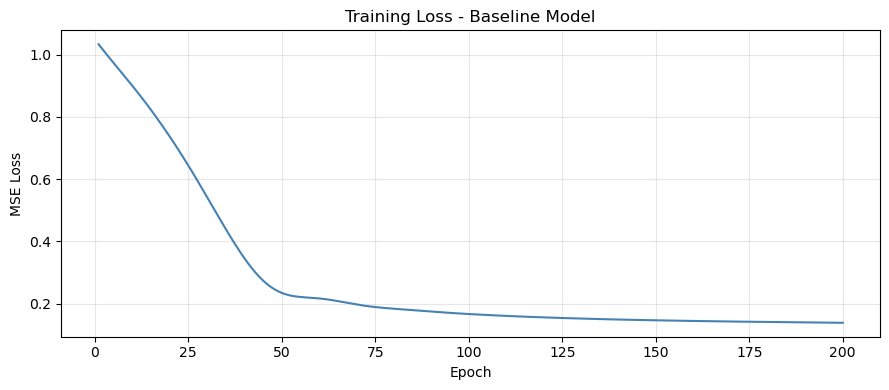

Final training loss: 0.138007


In [28]:
# Plot training loss
plt.figure(figsize=(9, 4))
plt.plot(range(1, epochs + 1), loss_history, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss - Baseline Model')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final training loss: {loss_history[-1]:.6f}")

# Question 05: [ Marks 10 ]

## Evaluate the model on test data.

## For regression:

Report MSE and MAE


## For classification:

Report Accuracy

Compare training vs testing performance.

State whether the model is underfitting or overfitting.

## Write Answer 05:

- Regression metrics used: **MSE** and **MAE**.
- Predictions are inverse-transformed to original dollar scale for readable MAE/MSE.
- Train vs test comparison is used for fit check:
  - Test >> Train: overfitting
  - Both high: underfitting
  - Close and low: good fit

In [29]:
# Evaluate on test set
model.eval()

with torch.no_grad():
    y_pred_test  = model(X_test_tensor)
    y_pred_train = model(X_train_tensor)

    # MSE in scaled space
    train_mse = criterion(y_pred_train, y_train_tensor).item()
    test_mse  = criterion(y_pred_test,  y_test_tensor).item()

    # Convert back to original dollar scale
    y_pred_orig = scaler_y.inverse_transform(y_pred_test.numpy())
    y_true_orig = scaler_y.inverse_transform(y_test_tensor.numpy())

    mae = np.mean(np.abs(y_pred_orig - y_true_orig))
    mse = np.mean((y_pred_orig - y_true_orig) ** 2)

print(f"Train MSE (scaled) : {train_mse:.6f}")
print(f"Test  MSE (scaled) : {test_mse:.6f}")
print(f"Test  MSE ($)      : {mse:,.0f}")
print(f"Test  MAE ($)      : {mae:,.0f}")

ratio = test_mse / max(train_mse, 1e-9)
if ratio < 1.3:
    print("Verdict: Good fit - model is not overfitting.")
elif ratio < 2.0:
    print("Verdict: Mild overfitting - test loss is a little higher than train loss.")
else:
    print("Verdict: Overfitting - test loss is much higher than train loss.")

Train MSE (scaled) : 0.137877
Test  MSE (scaled) : 0.146856
Test  MSE ($)      : 21,196,192
Test  MAE ($)      : 2,754
Verdict: Good fit - model is not overfitting.


# Question 06: [ Marks 20 ]

## Modify at least ONE of the following:

Learning rate

Number of hidden neurons

Number of epochs

### Train again and compare:

Convergence speed

Final performance

Explain how the change affected the model.

## Write Answer 06:

Changes made:
- Hidden layers: `64->32` to `128->64`
- Epochs: `200` to `400`
- Learning rate kept at `0.001`

Comparison focus: convergence speed and final train/test/MAE performance.

In [30]:
# Modified model - bigger hidden layers
class InsuranceNN_v2(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)


model_v2   = InsuranceNN_v2(num_features)
criterion2 = nn.MSELoss()
optimizer2 = torch.optim.Adam(model_v2.parameters(), lr=0.001)

epochs_v2     = 400
loss_history2 = []

for epoch in range(1, epochs_v2 + 1):
    y_pred2 = model_v2(X_train_tensor)
    loss2   = criterion2(y_pred2, y_train_tensor)

    optimizer2.zero_grad()
    loss2.backward()
    optimizer2.step()

    loss_history2.append(loss2.item())

    if epoch % 40 == 0:
        print(f"Epoch [{epoch:3d}/{epochs_v2}]  Loss: {loss2.item():.6f}")

print("Modified model training done!")

Epoch [ 40/400]  Loss: 0.182813
Epoch [ 80/400]  Loss: 0.146433
Epoch [120/400]  Loss: 0.136065
Epoch [160/400]  Loss: 0.128361
Epoch [200/400]  Loss: 0.121494
Epoch [240/400]  Loss: 0.114767
Epoch [280/400]  Loss: 0.108296
Epoch [320/400]  Loss: 0.101928
Epoch [360/400]  Loss: 0.095834
Epoch [400/400]  Loss: 0.089899
Modified model training done!


In [31]:
# Evaluate modified model
model_v2.eval()
with torch.no_grad():
    y_pred_v2_test  = model_v2(X_test_tensor)
    y_pred_v2_train = model_v2(X_train_tensor)

    train_mse_v2 = criterion2(y_pred_v2_train, y_train_tensor).item()
    test_mse_v2  = criterion2(y_pred_v2_test,  y_test_tensor).item()

    y_pred_v2_orig = scaler_y.inverse_transform(y_pred_v2_test.numpy())
    mae_v2 = np.mean(np.abs(y_pred_v2_orig - y_true_orig))
    mse_v2 = np.mean((y_pred_v2_orig - y_true_orig) ** 2)

print("Comparison:")
print(f"  Baseline  - Train MSE: {train_mse:.4f}  Test MSE: {test_mse:.4f}  MAE: ${mae:,.0f}")
print(f"  Modified  - Train MSE: {train_mse_v2:.4f}  Test MSE: {test_mse_v2:.4f}  MAE: ${mae_v2:,.0f}")

Comparison:
  Baseline  - Train MSE: 0.1379  Test MSE: 0.1469  MAE: $2,754
  Modified  - Train MSE: 0.0898  Test MSE: 0.1708  MAE: $2,893


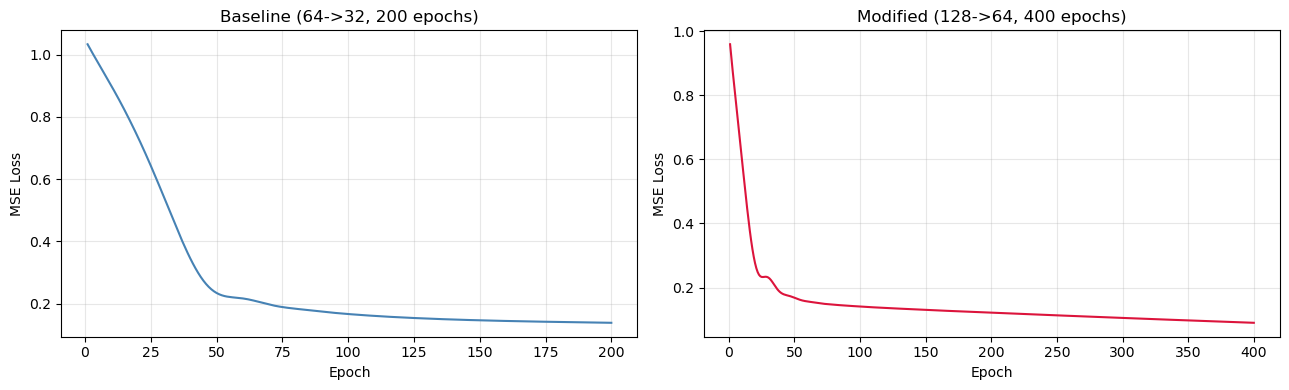

In [32]:
# Compare loss curves side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, epochs + 1), loss_history, color='steelblue')
axes[0].set_title('Baseline (64->32, 200 epochs)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, epochs_v2 + 1), loss_history2, color='crimson')
axes[1].set_title('Modified (128->64, 400 epochs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Question 07: [ Marks 20 ]


# Training Analysis

Answer the following:

Why must gradients be reset every epoch?

What happens if learning rate is too high?

What happens if learning rate is too small?

Why do we define layers inside the constructor (__init__) and not inside forward()?


## Write Answer 07:

**Why reset gradients every epoch?**
- PyTorch accumulates gradients after each `backward()` call.
- So we use `optimizer.zero_grad()` each epoch to avoid mixing old and new gradients.

**If learning rate is too high?**
- Weight updates become too large and can overshoot the minimum.
- Loss may oscillate or even diverge, so training becomes unstable.

**If learning rate is too small?**
- Weight updates are tiny, so training is very slow.
- Model may need many epochs and can get stuck before reaching a good solution.

**Why define layers in `__init__`, not `forward()`?**
- Layers in `__init__` are registered once, so optimizer and `state_dict()` can track them.
- If created inside `forward()`, new layers are made every pass, so parameters are not learned correctly.